<b><h2 style="color:blue;">IPB - Praksa</h2>
<h4>Grupa 4:</h4>
<h3 style="color: green">Simulacija Habitabilnosti planete Dragica </h3>


Model spaja više faktora i računa verovatnoću na osnovu:
$$H(r, h) = f_T(r,h) \cdot f_P(r,h) \cdot f_E(r,h) \cdot f_{pH}(r,h)$$

Gde su:
* $r$ — horizontalna udaljenost od hidrotermalnog izvora [km]
* $h$ — visina iznad dna okeana [km]
* $f_T$ — faktor temperature 
* $f_P$ — faktor dostupnosti fosfora
* $f_E$ — faktor dostupnosti energije
* $f_{pH}$ — faktor kiselosti

Svi faktori imaju vrednosti u opsegu $[0, 1]$.
kombinaciju $H(r, h) \in [0, 1]$ lokalna verovatnoća nastanjivosti.

In [161]:
# potrebne biblioteke
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
from matplotlib import rc
from matplotlib.colors import LogNorm
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import FancyArrowPatch, Rectangle
from scipy.ndimage import gaussian_filter
from scipy.integrate import simpson

In [162]:
# parametri sistema

# parametri zvezde 
ZVEZDA = {
    "klasa"          : "M3V",
    "T_eff_K"        : 3400, # efektivna temperatura [K]
    "masa_Msun"      : 0.45, # masa izrazena preko mase sun
    "radijus_Rsun"   : 0.42, # radijus -||-
    "metalicnost"    : 0.05, # [Fe/H]
    "luminoznost_Lsun": 0.02, # luminoznost preko lum. sunca
}

# parametri planete
PLANETA = {
    "masa_mEarth"    : 2.4, # masa izrazena preko mase zemlje
    "radijus_Rearth" : 1.25, # radijus -||-
    "gravitacija_g"  : 1.52, # površinska gravitacija -||-
    "orbita_AU"      : 0.20, # velika poluosa [AU]
    "ekscentricitet" : 0.02,
    "pritisak_bar"   : 2.0, # površinski atmosferski pritisak u barima
    "T_povrsina_C"   : -30.0, # površinska temperatura leda u celzijusima
}

# atmosferski sastav
ATM = {
    "CO2_mol_frac"   : 0.870, # molski udeo kad se prebaci u procente 87% 
    "N2_mol_frac"    : 0.100, 
    "Ar_mol_frac"    : 0.018,
    "H2O_mol_frac"   : 0.007,
    "H2_mol_frac"    : 0.003,
    "CH4_ppm"        : 80.0, # delova po milionu u procentima 0.008%
    "SO2_ppm"        : 25.0,
}

# parametri pod ledenog okeana
OKEAN = {
    "dubina_km"      : 40.0, # ukupna dubina okeana [km]
    "pH_bulk"        : 6.5, # pH daleko od termalnih izvora
    "salinitet_pct"  : 1.0, # salinitet [%]
    "T_led_C"        : -1.0, # temperatura na granici led–voda [C]
    "T_dno_C"        : 7.3, # ambijenalna temperatura dna [C]
}

# parametri termalnih izvora
VENT = {
    "T_crni_C"       : 258.0, # temperatura crnog pušača [C]
    "pH_vent"        : 4.5, # pH neposredno kod izvora
    "P_vent_uM"      : 50.0, # koncentracija fosfora kod izvora [mikroM]
    "H2_vent_mM"     : 15.0, # koncentracija H2 kod izvora [mM]
    "H2S_vent_mM"    : 3.0, # koncentracija H2S [mM]
}

# bioloski parametri
BIO = {
    "T_opt_C"        : 10.0, # optimalna temperatura [C]
    "T_sigma_C"      : 15.0, # sirina temp. prozora [C]
    "T_max_C"        : 110.0, # gornja granica [C]
    "T_min_C"        : -15.0, # donja granica [C]
    "Km_P_uM"        : 1.0, # Michaelis konstanta za fosfor [mikroM]
    "Km_E_mM"        : 0.10, # Michaelis konstanta za H2 [mM]
    "pH_opt"         : 6.0, # optimalni pH
    "pH_sigma"       : 1.5, # tolerancija pH
    "P_min_uM"       : 0.1, # minimalna koncentracija P za rast [mikroM]
}

# prostorni parametri modela
GRID = {
    "R_max_km"       : 300, # maksimalni horizontalni domet [km]
    "Nr"             : 401, # broj tačaka u r-pravcu
    "Nh"             : 251, # broj tačaka u h-pravcu
}


In [163]:
# pravljenje prostorne mreze
H_ok  = OKEAN["dubina_km"]
R_max = GRID["R_max_km"]
r = np.linspace(0.05, R_max, GRID["Nr"]) # km, mora 0.05 da se izbegne singularitet na r=0
h = np.linspace(0.0,  H_ok,  GRID["Nh"]) # km (0 = dno, H_ok = led)

R, H_grid = np.meshgrid(r, h) # oblici: (Nh, Nr)
print(R.shape) # istampa u konzolu oblik matrice u ovom slucaju nase mape
print(H_grid.shape)


(251, 401)
(251, 401)


Pre samog "jezgra" modela potrebno je popuniti mapu (matricu) koju smo dobili. Sledeći blok koda uzima svaki od definisanih faktora i za početak popunjava celu mapu. Prostim jezikom, za svaku koordinatu mape mi joj dodeljujemo vrednost za temperaturu, količinu fosfora, energiju, i pH vrednost.

In [164]:
T_background = OKEAN["T_led_C"] + (OKEAN["T_dno_C"] - OKEAN["T_led_C"]) * (1.0 - H_grid / H_ok)
print(np.flipud(T_background)) # dobije se matrica sa svim vrednostima temperature u svakom polju

[[-1.     -1.     -1.     ... -1.     -1.     -1.    ]
 [-0.9668 -0.9668 -0.9668 ... -0.9668 -0.9668 -0.9668]
 [-0.9336 -0.9336 -0.9336 ... -0.9336 -0.9336 -0.9336]
 ...
 [ 7.2336  7.2336  7.2336 ...  7.2336  7.2336  7.2336]
 [ 7.2668  7.2668  7.2668 ...  7.2668  7.2668  7.2668]
 [ 7.3     7.3     7.3    ...  7.3     7.3     7.3   ]]


Kod iznad nam daje temperaturu u svakoj koordinati na mapi ne uzimajući u obzir termalni izvor. Potrebno je sada odraditi korekciju za to.

In [165]:
#hidrotermalni izvor, eksponencijalni pad sa udaljenoscu i visinom
r_T = 4.0   # horizontalni domet [km]
h_T = 2.5   # vertikalni domet plumona [km]

T_plume = (VENT["T_crni_C"] - T_background) * np.exp(-R / r_T) * np.exp(-H_grid / h_T)
T_plume = np.maximum(T_plume, 0.0) # zastitna mera ako vrednosti odu u negativne (nema fizicki smisla da termalni izvor hladi vodu)

T_field = T_background + T_plume   # ukupno temperaturno polje [C]
print(np.flipud(T_field))

[[ -0.99997122  -0.99997614  -0.99998022 ...  -1.          -1.
   -1.        ]
 [ -0.96676932  -0.96677456  -0.96677891 ...  -0.9668      -0.9668
   -0.9668    ]
 [ -0.93356729  -0.93357288  -0.93357752 ...  -0.9336      -0.9336
   -0.9336    ]
 ...
 [225.13045933 187.88208632 157.00113548 ...   7.2336       7.2336
    7.2336    ]
 [239.53423053 199.8292806  166.91169231 ...   7.2668       7.2668
    7.2668    ]
 [254.88575458 212.56221414 177.47367023 ...   7.3          7.3
    7.3       ]]


Isti proces razmisljanja se primenjuje i kod fosfora. Kao izvor je uzeto oslobađanje iz apatita u bazaltnim stenama kroz hidrotermalne procese. On se zatim transportuje kroz okean u horizontalnom i vertikalnom pravcu, dok do gubitka dolazi u ovom modelu iz 2 efekta prvi je precipitacijom , a drugi je apsorpcija zbog gvozdje-oksihidroksid ($FeOOH$) tj. blizu izvora gde ima dosta $Fe^{3+}$.

In [166]:
r_P   = 30.0   # horizontalni transport [km]
h_P   = 18.0   # vertikalni opadajući transport [km]

P_transport = np.exp(-R / r_P) * np.exp(-H_grid / h_P)

# Ca-precipitacija: jaci efekat dalje od kiselih uslova venta -> nece biti tipican pad kao kod gausijana vec ce biti lorencijan koji opada kao x^(-2)
r_Ca  = 80.0
f_Ca  = 1.0 / (1.0 + (R / r_Ca)**2)

# apsorpcija, eksponencijalno opada sa udaljenoscu
r_Fe  = 10.0 
f_Fe  = 0.50 + 0.50 * np.exp(-R / r_Fe)

P_field = VENT["P_vent_uM"] * P_transport * f_Ca * f_Fe   # [mikroM]
P_field = np.maximum(P_field, 0.0)
print(P_field)

[[4.97922362e+01 4.68085711e+01 4.40577437e+01 ... 7.99598529e-05
  7.76216468e-05 7.53525805e-05]
 [4.93515999e+01 4.63943386e+01 4.36678547e+01 ... 7.92522482e-05
  7.69347341e-05 7.46857479e-05]
 [4.89148629e+01 4.59837720e+01 4.32814160e+01 ... 7.85509055e-05
  7.62539002e-05 7.40248164e-05]
 ...
 [5.49267084e+00 5.16353738e+00 4.86008868e+00 ... 8.82051471e-06
  8.56258300e-06 8.31227824e-06]
 [5.44406345e+00 5.11784266e+00 4.81707933e+00 ... 8.74245757e-06
  8.48680843e-06 8.23871873e-06]
 [5.39588621e+00 5.07255232e+00 4.77445059e+00 ... 8.66509119e-06
  8.41170442e-06 8.16581020e-06]]


Istom idejom se dobija i kod za energiju i pH. Kod energije je kao glavni izvor uzeta serpentizacija, dok je glavni gubitak mikrobioloska potrosnja.

In [167]:
r_E   = 15.0   # horizontalni domet [km]
h_E   = 12.0   # vertikalni domet [km]

E_field = VENT["H2_vent_mM"] * np.exp(-R / r_E) * (1.0 - np.exp(-H_grid / 2.0))
E_field = np.maximum(E_field, 0.0) # zastitna mera kao kod temp
print(E_field, "\n")

r_pH  = 8.0 # gde se vraca pH u optimalan od izvora [km]
pH_field = OKEAN["pH_bulk"] - (OKEAN["pH_bulk"] - VENT["pH_vent"]) * np.exp(-R / r_pH)
print(pH_field)

[[0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [1.14941702e+00 1.09336840e+00 1.04005286e+00 ... 2.62698652e-09
  2.49888770e-09 2.37703532e-09]
 [2.21046266e+00 2.10267465e+00 2.00014266e+00 ... 5.05200072e-09
  4.80565178e-09 4.57131547e-09]
 ...
 [1.49500832e+01 1.42210776e+01 1.35276201e+01 ... 3.41683361e-08
  3.25021975e-08 3.09173043e-08]
 [1.49500832e+01 1.42210776e+01 1.35276201e+01 ... 3.41683361e-08
  3.25021975e-08 3.09173043e-08]
 [1.49500832e+01 1.42210776e+01 1.35276201e+01 ... 3.41683361e-08
  3.25021975e-08 3.09173043e-08]] 

[[4.51246102 4.69029689 4.85222082 ... 6.5        6.5        6.5       ]
 [4.51246102 4.69029689 4.85222082 ... 6.5        6.5        6.5       ]
 [4.51246102 4.69029689 4.85222082 ... 6.5        6.5        6.5       ]
 ...
 [4.51246102 4.69029689 4.85222082 ... 6.5        6.5        6.5       ]
 [4.51246102 4.69029689 4.85222082 ... 6.5        6.5        6.5       ]
 [4.51246102 4.69029689 4.85

Kada su popunjena sva polja mape za svaki od 4 odabrana faktora sada je vreme da se sve to spoji. Kao što je vec navedeno, svaki habitabilni faktor je broj u opsegu $[0, 1]$. Vrednost 0 označava potpuno nepogodne uslove a 1 idealne. 

Temperatura ce biti modelovana Gausijanom ( $f(x) = \frac{1}{\sqrt{2\pi \sigma^2}}e^{(-\frac{(x-\mu)^2}{2\sigma^2})}$ ) oko optimalne temperature koja je u nasem slučaju promenljiva T_opt_C te formula postaje $f_T = e^{(-(T\_field - T\_opt\_C) / T\_sigma\_C)^2}$. Izostavljamo prvi deo formule jer nam je potrebna normalizacija tako da se max vrednost postigne kada se poklope optimalna temperatura i temperatura u matrici, što je u našem sučaju ta maksimalna vrednost od 1. Takođe $f_T$ će biti 0 ako pređe gornju i donju granicu

In [168]:
f_T = np.exp(-((T_field - BIO["T_opt_C"]) / BIO["T_sigma_C"])**2)
f_T[T_field > BIO["T_max_C"]] = 0.0   # gornja granica
f_T[T_field < BIO["T_min_C"]] = 0.0   # donja granica
print(f_T)

[[0.         0.         0.         ... 0.96811926 0.96811926 0.96811926]
 [0.         0.         0.         ... 0.96734343 0.96734343 0.96734343]
 [0.         0.         0.         ... 0.96655875 0.96655875 0.96655875]
 ...
 [0.58783925 0.58783893 0.58783867 ... 0.58783738 0.58783738 0.58783738]
 [0.58594259 0.58594229 0.58594204 ... 0.58594084 0.58594084 0.58594084]
 [0.58404633 0.58404605 0.58404582 ... 0.58404469 0.58404469 0.58404469]]


Isti Gausijan se primenjuje i na pH.

In [169]:
f_pH = np.exp(-((pH_field - BIO["pH_opt"]) / BIO["pH_sigma"])**2)
print(f_pH)

[[0.37401689 0.4665615  0.55682192 ... 0.89483932 0.89483932 0.89483932]
 [0.37401689 0.4665615  0.55682192 ... 0.89483932 0.89483932 0.89483932]
 [0.37401689 0.4665615  0.55682192 ... 0.89483932 0.89483932 0.89483932]
 ...
 [0.37401689 0.4665615  0.55682192 ... 0.89483932 0.89483932 0.89483932]
 [0.37401689 0.4665615  0.55682192 ... 0.89483932 0.89483932 0.89483932]
 [0.37401689 0.4665615  0.55682192 ... 0.89483932 0.89483932 0.89483932]]


Što se tiče fosfora i energije koristimo Michaelis-Menten kinetiku. Po uzoru na python paket, NutMEG, koji koristi Michaelis–Menten–Monod. Svesni da ova opcija nije najbolja ili najsofiticiraniji opis ovih faktora. Ovaj jednostavniji model je 'dovoljno dobar' za nase trenutne potrebe. Vise o oba algoritma i NutMEG paketu moguće je pročitati na: 
https://en.wikipedia.org/wiki/Michaelis%E2%80%93Menten_kinetics
https://en.wikipedia.org/wiki/Michaelis%E2%80%93Menten%E2%80%93Monod_kinetics
https://higginsetal.com/docs/html/index.html

In [170]:
# MM za fosfor
# 0 bez fosfora, 1 pri max zasicenju
f_P = P_field / (P_field + BIO["Km_P_uM"])
print(f_P,"\n")

# MM za energiju
f_E = E_field / (E_field + BIO["Km_E_mM"])
print(f_E)

[[9.80311952e-01 9.79083249e-01 9.77806257e-01 ... 7.99534598e-05
  7.76156222e-05 7.53469029e-05]
 [9.80139658e-01 9.78900433e-01 9.77612536e-01 ... 7.92459678e-05
  7.69288156e-05 7.46801703e-05]
 [9.79965887e-01 9.78716055e-01 9.77417163e-01 ... 7.85447357e-05
  7.62480860e-05 7.40193371e-05]
 ...
 [8.45980179e-01 8.37755507e-01 8.29354118e-01 ... 8.82043691e-06
  8.56250969e-06 8.31220914e-06]
 [8.44818412e-01 8.36543688e-01 8.28092425e-01 ... 8.74238114e-06
  8.48673641e-06 8.23865086e-06]
 [8.43649501e-01 8.35324597e-01 8.26823352e-01 ... 8.66501611e-06
  8.41163367e-06 8.16574352e-06]] 

[[0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [9.19962672e-01 9.16203580e-01 9.12284769e-01 ... 2.62698645e-08
  2.49888764e-08 2.37703526e-08]
 [9.56718625e-01 9.54600649e-01 9.52384187e-01 ... 5.05200046e-08
  4.80565155e-08 4.57131527e-08]
 ...
 [9.93355518e-01 9.93017285e-01 9.92661962e-01 ... 3.41683244e-07
  3.25021869e-07 3.09172947e-0

Sva četiri faktora se sada mnoze iz prostog razloga što svi uslovi moraju biti istovremeno zadovoljeni. Nedostatak jednog faktora utiče na ukupnu habitabilnost, bez obzira na ostale. Alternativa mogu da budu geometrijske ili aritmetičke sredine, ali oni nisu dovoljno bioloski i fizički precizni jer, primera radi, organizam koji nema odgovarajuću temperaturu ne moze da prezivi nasuprot tome da su svi ostali uslovi ispunjeni.

In [171]:
H_map = f_T * f_P * f_E * f_pH
print(H_map)

[[0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 1.80202474e-12
  1.66403140e-12 1.53662066e-12]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 3.43205136e-12
  3.16923569e-12 2.92657515e-12]
 ...
 [1.84762868e-01 2.28160963e-01 2.69473374e-01 ... 1.58531671e-12
  1.46391519e-12 1.35182417e-12]
 [1.83913818e-01 2.27095838e-01 2.68195309e-01 ... 1.56621812e-12
  1.44627914e-12 1.33553849e-12]
 [1.83064983e-01 2.26031031e-01 2.66917690e-01 ... 1.54733444e-12
  1.42884155e-12 1.31943608e-12]]


Sada je bitno koji je to procenat okeana nastanjiv. Opet ovo se odnosi samo na cilindar oko termalnog izvora. To je i glavna mana ovog modela jer posmatra samo okolinu 1 izvora i racuna da postoji samo taj jedan izvor. Zato kada se kaze procenat nastanjivosti misli se na cilindar oko tog jednog izvora. Kao sto smo rekli racunamo $f_{hab} = \frac{V_{nastanjivo}}{V_{ukupno}}$. Na prvi pogled nije najjasnije kako se dolazi do ovih vrednosti, u nastavku sledi kratko objašnjenje. Zapremina u cilindricnim koord. $$dV = rdrd\theta dh$$ Kako je sistem simetričan znači da nema preferiranog pravca $\int_{0}^{2\pi}d\theta = 2\pi$. Pa formula iznad postaje: $$dV = 2\pi rdrdh$$ Ukupna zapremina se dobija kada se odradi dvosturki integral: $$V_{ukupno} = \int_{0}^{H_{okean}}\int_{0}^{R_{max}}2\pi rdrdh$$ Nastanjiva zaprermina će biti:
$$V_{nastanjivo} = \int_{0}^{H_{okean}}\int_{0}^{R_{max}}H(r, h)2\pi rdrdh$$
Kada se ovo sve vrati u početnu formulu dobija se:
$$f_{hab} = \frac{\int \int H(r, h)2\pi rdrdh}{\int \int 2\pi rdrdh}$$

In [172]:
dV = 2.0 * np.pi * R 
V_total = simpson(simpson(dV, h, axis=0), r)
integrand = H_map * dV
V_habitable = simpson(simpson(integrand, h, axis=0), r)

# nastanjivi udeo [%]
f_hab = V_habitable / V_total * 100.0

# nije toliko bitno u siroj slici jer zavisi od R koje izaberemo na pocetku, ako stavim manje R nastanjivi udeo raste.
print(f"Ukupna zapremina: {V_total:.3f} km^3")
print(f"Nastanjiva zapremina: {V_habitable:.3f} km^3")
print(f"Nastanjivi udeo: {f_hab:.2f} % \n")

# lokacija maksimuma habitabilnosti
idx_max  = np.unravel_index(np.argmax(H_map), H_map.shape)
r_peak   = float(r[idx_max[1]])
h_peak   = float(h[idx_max[0]])
H_peak   = float(H_map[idx_max])

print(f"Verovatnoca u piku: {H_peak*100:.2f}%")
print(f"Lokacija pika: r={r_peak:.1f} km, h={h_peak:.1f} km\n")


# srednje vrednosti faktora u nastanjivoj zoni (H >= 0)
mask_hab = H_map >= 0.1
def mean_in_zone(arr):
    return float(np.mean(arr[mask_hab])) if mask_hab.any() else 0.0

mean_fT  = mean_in_zone(f_T)
mean_fP  = mean_in_zone(f_P)
mean_fE  = mean_in_zone(f_E)
mean_fpH = mean_in_zone(f_pH)

print("Srednje vrednosti faktora u nastanjivoj zoni:")
print(f"Temperatura: {mean_fT:.2f}")
print(f"Fosfor: {mean_fP:.2f}")
print(f"Energija: {mean_fE:.2f}")
print(f"pH: {mean_fpH:.2f}")

# za limitirajuci faktor uzimamo minimum od svih
limiting = min(mean_fT, mean_fP, mean_fE, mean_fpH)
lim_name = {mean_fT:"Temperatura", mean_fP:"Fosfor", mean_fE:"Energija",
             mean_fpH:"pH"}[limiting]
print(f"Limitirajuci faktor je {lim_name}")

Ukupna zapremina: 11309733.239 km^3
Nastanjiva zapremina: 253081.053 km^3
Nastanjivi udeo: 2.24 % 

Verovatnoca u piku: 93.40%
Lokacija pika: r=10.5 km, h=4.0 km

Srednje vrednosti faktora u nastanjivoj zoni:
Temperatura: 0.81
Fosfor: 0.65
Energija: 0.86
pH: 0.90
Limitirajuci faktor je Fosfor


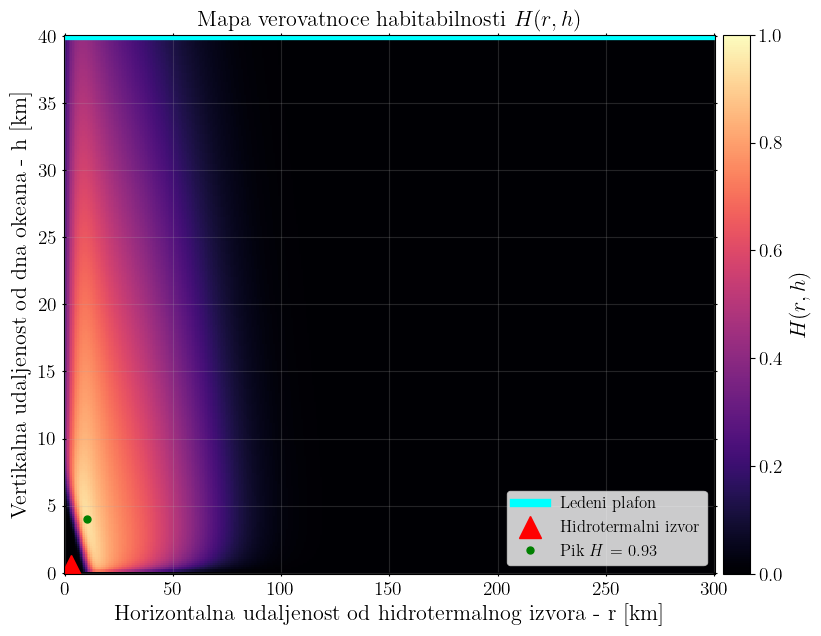

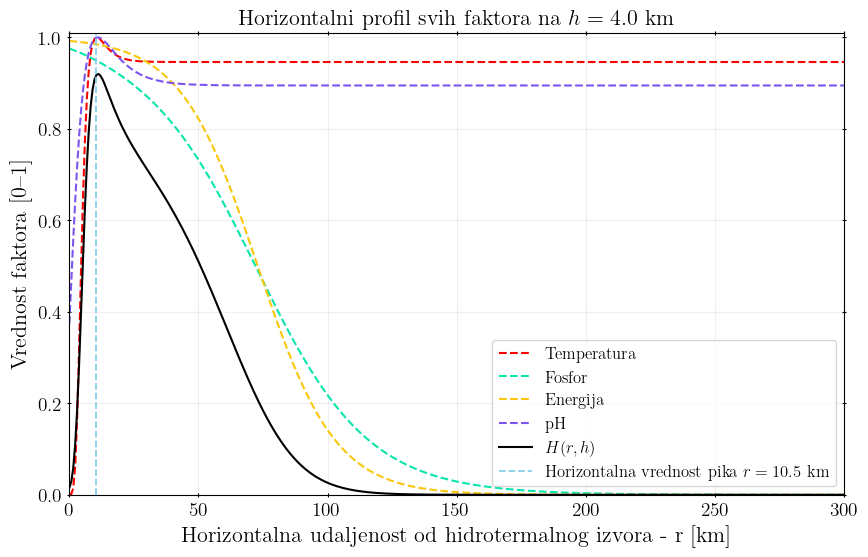

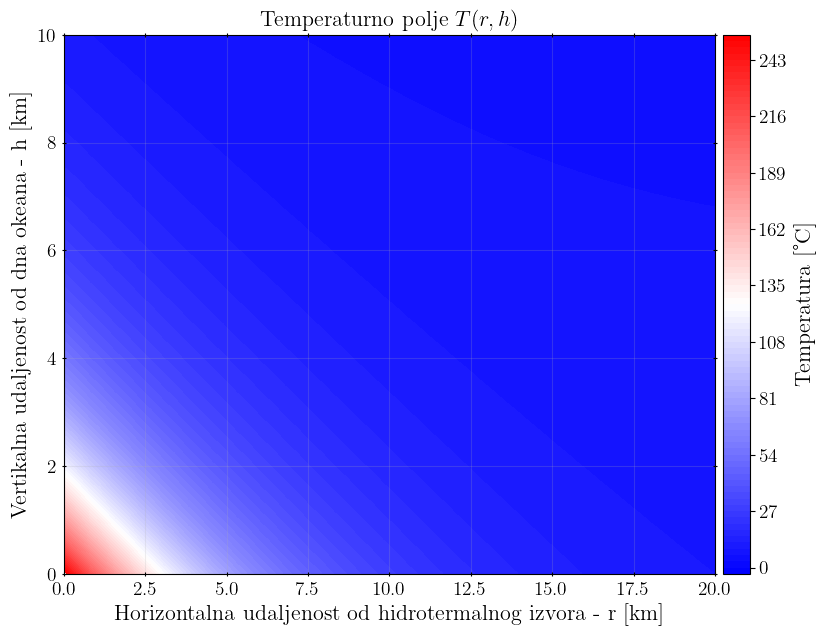

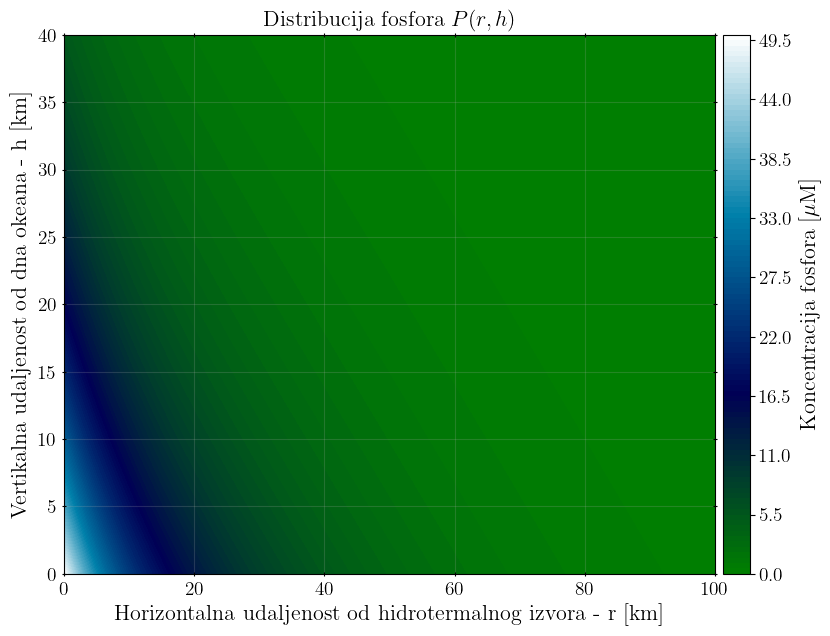

In [173]:
# globalni parametri za stilizaciju grafika
rc('text', usetex=True)
rc('font', size=12)
rc('axes', titlesize=16)
rc('axes', labelsize=16)
rc('xtick', labelsize=14)
rc('ytick', labelsize=14)
rc('legend', fontsize=12)
rc('figure', titlesize=16)
plt.rcParams["font.family"] = "Times New Roman"
#plt.style.use('dark_background') # opcija ako zelijmo crne grafike za prezentaciju

# vizualizacija podataka

# plot verovatnoce habitabilnosti
plt.figure(figsize=(10, 7))
plt.pcolormesh(R, H_grid, H_map, cmap='magma', vmin=0, vmax=1)
plt.colorbar(label=f'$H(r, h)$', pad=0.01)
plt.axhline(H_ok, color='cyan', linewidth=6, label='Ledeni plafon')
plt.plot([3], [0.5], 'r^', markersize=16, label='Hidrotermalni izvor')
plt.plot(r_peak, h_peak, 'g.', markersize=10, label=f'Pik $H$ = {H_peak:.2f}')
plt.xlabel('Horizontalna udaljenost od hidrotermalnog izvora - r [km]')
plt.ylabel('Vertikalna udaljenost od dna okeana - h [km]')
plt.title(f'Mapa verovatnoce habitabilnosti $H(r, h)$')
plt.tick_params(direction='inout', top=True, right=True)
plt.legend(loc='lower right')
plt.grid(alpha=0.2)
plt.savefig('mapa_verovatnoce.png', dpi=300, bbox_inches='tight')
plt.show()

# 1D konture faktora
hi = idx_max[0] 
H_smooth = gaussian_filter(H_map, sigma=2.0) 
COLORS_F = {"f_T":"#fa0202","f_P":"#0ae6ab","f_E":"#fac70d","f_pH":"#7c55f0"}

plt.figure(figsize=(10, 6))
plt.plot(r, f_T[hi, :],  color=COLORS_F["f_T"],  lw=1.5, ls="--", label="Temperatura")
plt.plot(r, f_P[hi, :],  color=COLORS_F["f_P"],  lw=1.5, ls="--", label="Fosfor")
plt.plot(r, f_E[hi, :],  color=COLORS_F["f_E"],  lw=1.5, ls="--", label="Energija")
plt.plot(r, f_pH[hi, :], color=COLORS_F["f_pH"], lw=1.5, ls="--", label="pH")
plt.plot(r, H_smooth[hi,:], '-', linewidth=1.5, label=f'$H(r, h)$', color='black')
plt.xlabel('Horizontalna udaljenost od hidrotermalnog izvora - r [km]')
plt.ylabel(f'Vrednost faktora $[0–1]$')
plt.title(f'Horizontalni profil svih faktora na $h = {h_peak:.1f}$ km')
plt.axvline(r_peak, color='skyblue', ls='--', linewidth=1.3, label=f'Horizontalna vrednost pika $r = {r_peak:.1f}$ km')
plt.xlim(0, R_max)
plt.ylim(0, 1.01)
plt.tick_params(direction='inout', top=True, right=True)
plt.legend(loc='lower right')
plt.grid(alpha=0.2)
plt.savefig('horizontalni_profil_faktora.png', dpi=300, bbox_inches='tight')
plt.show()

# temperaturno polje
plt.figure(figsize=(10, 7))
plt.contourf(R, H_grid, T_field, levels=100, cmap='bwr')
plt.colorbar(label=f'Temperatura [°C]',pad=0.01)
plt.xlabel('Horizontalna udaljenost od hidrotermalnog izvora - r [km]')
plt.ylabel('Vertikalna udaljenost od dna okeana - h [km]')
plt.title(f'Temperaturno polje $T(r, h)$')
plt.xlim(0, 20)
plt.ylim(0, 10)
plt.grid(alpha=0.2)
plt.tick_params(direction='inout', top=True, right=True)
plt.savefig('temperaturno_polje.png', dpi=300, bbox_inches='tight')
plt.show()

# fosforno polje
plt.figure(figsize=(10, 7))
plt.contourf(R, H_grid, P_field, levels=100, cmap='ocean')
plt.colorbar(label=f'Koncentracija fosfora [$\\mu$M]', pad=0.01)
plt.xlabel('Horizontalna udaljenost od hidrotermalnog izvora - r [km]')
plt.ylabel('Vertikalna udaljenost od dna okeana - h [km]')
plt.title('Distribucija fosfora $P(r, h)$')
plt.xlim(0, 100)  
plt.ylim(0, H_ok) 
plt.grid(alpha=0.2)
plt.tick_params(direction='inout', top=True, right=True)
plt.savefig('fosforno_polje.png', dpi=300, bbox_inches='tight')
plt.show()